In [1]:
import numpy as np
import seaborn as sns
import random
import pandas as pd
import matplotlib.pyplot as plt
import math
from copy import deepcopy

In [2]:
# metod generise rcbd tabelu tako sto je popuni sa nasumicnim brojevima iz [lower, upper] --> ovo je okej jer mi radimo sa vestackim podacima
# generalno gledano to nisu nasumicne vrednosti vec izmerene vrednosti u eksperimentu
def generate_rcbd_table(n_rows = 2, n_cols = 2, lower_bound = 1, upper_bound = 30, seed=None):
    if seed is not None:
        np.random.seed(seed)

    #data = np.random.randint(lower_bound, upper_bound + 1, size=(n_rows, n_cols))
    data = np.round(np.random.uniform(lower_bound, upper_bound, size=(n_rows, n_cols)), 1)

    df = pd.DataFrame(data,
                      index=[f"T{i+1}" for i in range(n_rows)],
                      columns=[f"B{j+1}" for j in range(n_cols)])
    return df

In [3]:
def calculate_sse(predicted, true = None, mask=None):
    predicted = predicted.astype(float)
    # check if its corrent for else case
    if true is not None and mask is not None:
      true = true.astype(float)
      error = (predicted - true) ** 2
      #print("Error matrix:\n", error)
      masked_error = error * mask
      #print("Masked error matrix:\n", masked_error)
      sse = np.sum(masked_error)
    else:
      # in this case, data isnt artifically generated so we actually dont know the missing value at all and only have predicted matrix
      # model based SSE

      sample_mean = predicted.mean()
      row_means = predicted.mean(axis=1)
      col_means = predicted.mean(axis=0)

      sse = 0
      for i in range(predicted.shape[0]):
          for j in range(predicted.shape[1]):
              y_ij = predicted[i, j]
              y_hat_ij = row_means[i] + col_means[j] - sample_mean
              sse += (y_ij - y_hat_ij) ** 2
    return sse

<h4>Test primeri i vizualizacija razlike<h4>

In [4]:
# originalna RCBD tabela (npr. 3 tretmana x 3 bloka)
true_table = generate_rcbd_table(3, 3, 1, 20, 42)
display(true_table)
# maska:
mask = pd.DataFrame(0, index=true_table.index, columns=true_table.columns)
# izaberemo proizvoljna polja za promenu
mask.iloc[0, 1] = 1
mask.iloc[2, 2] = 1

# predlozene vrednosti koje bi GA dao kao rešenja
predicted_table = true_table.copy().astype(float)
predicted_table.iloc[0, 1] = 19.5
predicted_table.iloc[2, 2] = 12.5
sse = calculate_sse(predicted_table.values, true_table.values, mask.values)
print(f"SSE: {sse:.4f}")

,B1,B2,B3
T1,8.1,19.1,14.9
T2,12.4,4.0,4.0
T3,2.1,17.5,12.4


SSE: 0.1700


In [5]:
error_table = (predicted_table - true_table)
masked_error_table = error_table * mask

print("Razlika (samo na pozicijama sa greškom):")
display(masked_error_table)

Razlika (samo na pozicijama sa greškom):


,B1,B2,B3
T1,0.0,0.4,0.0
T2,0.0,0.0,0.0
T3,0.0,0.0,0.1


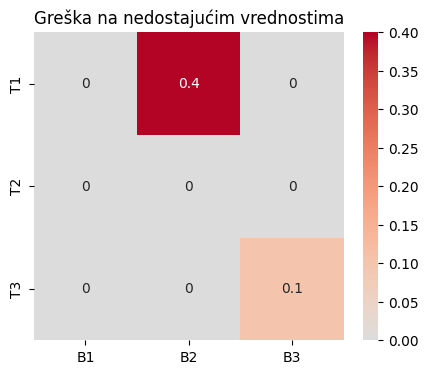

In [6]:
plt.figure(figsize=(5,4))
sns.heatmap(masked_error_table, annot=True, cmap="coolwarm", center=0)
plt.title("Greška na nedostajućim vrednostima")
plt.show()

In [7]:
#nasumicno uklanjanje jedne vrednosti iz rcbd tabele
def hide_random_value(table: pd.DataFrame, num_missing=1, seed=None):
    assert num_missing in [1, 2], "Only 1 or 2 missing values supported."
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    table_hidden = table.copy() #kopija tabele sa jednom vrednošću zamenjenom sa np.nan

    rows, cols = table.shape
    total_cells = [(i, j) for i in range(rows) for j in range(cols)]

    hidden_positions = random.sample(total_cells, num_missing)
    true_values = [table_hidden.iat[i, j] for i, j in hidden_positions]

    for i, j in hidden_positions:
        table_hidden.iat[i, j] = np.nan

    return table_hidden, hidden_positions, true_values

In [8]:
#proba funkcije za uklanjanje jedne vrednosti
df = generate_rcbd_table(5, 5, 10, 50, 46)
print("Originalna tabela:")
display(df)

df_hidden, pos, original_val = hide_random_value(df, 2, 46)

print("\nTabela sa skrivenom vrednošću:")
display(df_hidden)

print(f"\nUklonjena vrednost: {original_val} na poziciji {pos}")

Originalna tabela:


,B1,B2,B3,B4,B5
T1,41.4,35.4,20.0,40.3,22.5
T2,47.5,11.7,27.6,46.5,28.2
T3,30.3,13.4,27.1,39.8,44.7
T4,22.9,14.2,42.1,25.8,35.1
T5,11.4,22.0,11.9,24.9,20.5



Tabela sa skrivenom vrednošću:


,B1,B2,B3,B4,B5
T1,41.4,35.4,NaN,40.3,22.5
T2,47.5,11.7,27.6,46.5,28.2
T3,30.3,13.4,NaN,39.8,44.7
T4,22.9,14.2,42.1,25.8,35.1
T5,11.4,22.0,11.9,24.9,20.5



Uklonjena vrednost: [np.float64(20.0), np.float64(27.1)] na poziciji [(0, 2), (2, 2)]


In [9]:
class Individual:
    def __init__(self, rcbd : pd.DataFrame, rcbd_true : pd.DataFrame = None):
        self.code = calculate_code(rcbd)
        self.rcbd = rcbd; # original rcbd with missing values because it is passed by reference
        self.rcbd_true = rcbd_true # optional, we dont have this with real data
        self.second_nan = self.calculate_second_nan()
        self.fitness = self.calc_fitness()

    def calc_fitness(self):
        rcbd_c = self.rcbd.copy()
        # if chromosome code isnt in allowed range, fitness is set to -inf
        decode_value, row1, col1 = self.decode()

        nan_positions = list(zip(*np.where(rcbd_c.isna())))
        # we need to insert the predicted second missing value if there were the second one
        if self.second_nan is not None and len(nan_positions) > 1:
            row2, col2 = nan_positions[1]
            rcbd_c.iloc[row2, col2] = self.second_nan # update table with both values filled

        t_values = rcbd_c.iloc[row1].dropna().values.astype(float)
        t_scaled = [int(round(v * 10)) for v in t_values]
        min_s = min(t_scaled)
        max_s = max(t_scaled)

        eps_s = max(1, (max_s - min_s) // 10)

        min_value = (min_s - eps_s) / 10.0
        max_value = (max_s + eps_s) / 10.0

        if decode_value < min_value or decode_value > max_value:
            return -float("inf")

        rcbd_c.iloc[row1, col1] = decode_value

        if self.rcbd_true is not None:
          mask = pd.DataFrame(0, index=rcbd_c.index, columns=rcbd_c.columns)
          mask.iloc[row1, col1] = 1
          return -calculate_sse(rcbd_c.values, self.rcbd_true.values, mask.values)
        else:
          return -calculate_sse(rcbd_c.values)

    def binary_code(self):
      return ''.join(['1' if bit else '0' for bit in self.code])

    def decode(self):
      # (min (row where nan is) + int(self.code)) / 10
      t_row_ids, t_col_ids = np.where(self.rcbd.isna())
      t_row_id = t_row_ids[0]
      t_col_id = t_col_ids[0]

      t_values = self.rcbd.iloc[t_row_id].dropna().values.astype(float) # it doesnt modify rcbd
      t_scaled = [int(round(v * 10)) for v in t_values]

      min_value = min(t_scaled)
      max_value = max(t_scaled)

      epsilon = max(1, (max_value - min_value) // 10)
      min_value -= epsilon

      decoded_value = (min_value + int(self.binary_code(), 2))
      decoded_value = decoded_value / 10.0  # nazad u decimale

      return decoded_value, t_row_id, t_col_id

    def __str__(self):
        binary = self.binary_code()
        decoded_value, row, col = self.decode()
        return f"Chromosome binary code is {binary} and decoded value is {decoded_value} (at row {row}, column {col})\n"

    def calculate_second_nan(self):
        # find the position of the second missing value in the rcbd
        rcbd_c = self.rcbd.copy()
        nan_positions = list(zip(*np.where(rcbd_c.isna())))
        if len(nan_positions) < 2:
            return None;
        # calculate second_nan based on equation from scientific paper
        # for that we will first need to insert predicted first missing value so copy of rcbd will be created.
        decoded, first_row, first_col = self.decode()
        rcbd_c.iloc[first_row, first_col] = decoded

        row, col = nan_positions[1]
        # then we need to calculate all the params for the equation
        a = self.rcbd.shape[0]  # number of rows (blocks)
        b = self.rcbd.shape[1]  # number of columns (treatments)
        row_sum = rcbd_c.iloc[row].dropna().sum()
        col_sum = rcbd_c.iloc[:, col].dropna().sum()
        total_sum = rcbd_c.stack().sum()

        second_nan = (a * row_sum + b * col_sum - total_sum) / ((a - 1) * (b - 1))
        return second_nan

In [31]:
# this function returns code for given individual (chromosome). Each individual should represent the missing value in the RCBD table.
def calculate_code(table : pd.DataFrame):
  # first we need to determine range for missing value.
  t_row_ids, _ = np.where(table.isna()) # treatment where the missing value occurs
  t_row_id = t_row_ids[0]

  # remove from the t_row_id the nan value
  t_values = table.iloc[t_row_id].dropna().values.astype(float)
  # scale all values as int
  t_rounded_values = [round(v, 1) for v in t_values]
  t_scaled_values = [int(round(v * 10)) for v in t_rounded_values]

  min_value = min(t_scaled_values)
  max_value = max(t_scaled_values)

  epsilon = max(1, (max_value - min_value) // 10) #never be 0

  min_value -= epsilon
  max_value += epsilon

  n = max_value - min_value + 1  # number of values in [min - eps, max + eps]
  size = math.ceil(math.log2(n)) # size of the chromosome
  chromosome = [random.random() < 0.7 for _ in range(size)]

  return chromosome

In [32]:
chromosome = Individual(df_hidden, df)

In [33]:
print(type(chromosome))

<class '__main__.Individual'>


In [34]:
print("Random generated chromosome: ", chromosome.binary_code())

Random generated chromosome:  10101110


In [35]:
decoded_val, row, col = chromosome.decode()
print(f"Decoded value: {decoded_val} and row: {row}, col: {col} where missing value was.")

Decoded value: 38.1 and row: 0, col: 2 where missing value was.


In [36]:
print("Fitness of this random generated chromosome is: ", chromosome.fitness)

Fitness of this random generated chromosome is:  -327.61000000000007


In [37]:
def initial_population(rcbd : pd.DataFrame, rcbd_true: pd.DataFrame = None, size = 10):
    population = []
    while True:
        if rcbd_true is not None:
          chromosome = Individual(rcbd, rcbd_true)
        else:
          chromosome = Individual(rcbd) # TO DO: fix fitness in this case
        decode_value, row, _ = chromosome.decode()

        # condition: decoded chromosome in range [min_value, max_value]
        t_values = rcbd.iloc[row].dropna().values.astype(float)
        t_scaled = [int(round(v * 10)) for v in t_values]
        min_s = min(t_scaled)
        max_s = max(t_scaled)
        eps_s = max(1, (max_s - min_s) // 10)

        min_value = (min_s - eps_s) / 10.0
        max_value = (max_s + eps_s) / 10.0

        if decode_value <= max_value and decode_value >= min_value:
            population.append(chromosome)

        if len(population) == size:
            break

    return population

In [38]:
population = initial_population(df_hidden, df)

In [39]:
for individual in population:
    print(individual)

Chromosome binary code is 01111011 and decoded value is 33.0 (at row 0, column 2)

Chromosome binary code is 10100110 and decoded value is 37.3 (at row 0, column 2)

Chromosome binary code is 10111011 and decoded value is 39.4 (at row 0, column 2)

Chromosome binary code is 11010101 and decoded value is 42.0 (at row 0, column 2)

Chromosome binary code is 01111101 and decoded value is 33.2 (at row 0, column 2)

Chromosome binary code is 00110110 and decoded value is 26.1 (at row 0, column 2)

Chromosome binary code is 01110111 and decoded value is 32.6 (at row 0, column 2)

Chromosome binary code is 01111100 and decoded value is 33.1 (at row 0, column 2)

Chromosome binary code is 01101110 and decoded value is 31.7 (at row 0, column 2)

Chromosome binary code is 01011011 and decoded value is 29.8 (at row 0, column 2)



In [40]:
#Selecting individuals from the population based on roulette selection
def roulette_selection(population, num_selected=2, epsilon=1e-6):
    assert num_selected <= len(population), "Cannot select more individuals than population size without replacement."
    # check if its correct
    # assert not any(np.array_equal(candidate.code, other.code) for other in selected) == False, "Cannot select more individuals than population size without replacement."
    population = [ind for ind in population if not np.isinf(ind.fitness)]
    fitness_values = np.array([ind.fitness for ind in population])

    min_fit = np.min(fitness_values)
    shifted_fitness = fitness_values - min_fit + epsilon

    total = np.sum(shifted_fitness)
    # probabilities = shifted_fitness / total
    if not np.isfinite(total) or total <= 0:
      probabilities = np.full(len(population), 1.0 / len(population))
    else:
      probabilities = shifted_fitness / total

    selected = []
    while True:
        idx = np.random.choice(len(population), p=probabilities)
        candidate = population[idx]
        if not any(np.array_equal(candidate.code, other.code) for other in selected):
          selected.append(candidate)
        if len(selected) == num_selected:
          break;

    return selected




In [41]:
# two-point crossover between parents if number of bits in code is bigger, else one-point
# 10 001 1
# 11 111 0
# 10 111 1
# 11 001 0
def crossover(parent1: Individual, parent2: Individual, child1: Individual, child2: Individual):
    # randomly select two breakpoints
    bp1 = random.randrange(1, len(parent1.code)) # first and last position are excluded because we want to take the middle part of the parent
    # with few bits, crossover often swaps only one identical bit, producing identical offsprings to parents.

    if len(parent1.code) < 5:
        child1.code[:bp1] = parent1.code[:bp1]
        child1.code[bp1:] = parent2.code[bp1:]

        child2.code[:bp1] = parent2.code[:bp1]
        child2.code[bp1:] = parent1.code[bp1:]
    bp2 = bp1
    while bp2 == bp1:
        bp2 = random.randrange(1, len(parent1.code))

    bps = sorted([bp1, bp2])

    child1.code[:bps[0]] = parent1.code[:bps[0]]
    child1.code[bps[0]:bps[1]] = parent2.code[bps[0]:bps[1]]
    child1.code[bps[1]:] = parent1.code[bps[1]:]

    child2.code[:bps[0]] = parent2.code[:bps[0]]
    child2.code[bps[0]:bps[1]] = parent1.code[bps[0]:bps[1]]
    child2.code[bps[1]:] = parent2.code[bps[1]:]

In [42]:
def mutation(child: Individual, mutation_prob = 0.2):
  # mutation is performed such as following : randomly select two breaking points and invert all the bits between them
  bp1 = random.randrange(1, len(child.code))
  bp2 = bp1
  while bp2 == bp1:
      bp2 = random.randrange(1, len(child.code))

  bps = sorted([bp1, bp2])
  if random.random() < mutation_prob:
    for i in range(bps[0], bps[1]):
      child.code[i] = not child.code[i]

In [43]:
def ga(initial_population, num_generations, elitism_size, mutation_prob):
    new_population = [Individual(initial_population[0].rcbd, initial_population[0].rcbd_true) for _ in range(len(initial_population))]

    # if elitism_size % 2 != population_size % 2:
    #     elitism_size += 1

    best_fitnesses = []
    best_decoded_values = []
    mean_mapes = [] # calculating maps for second missing value by equation from the paper
    population = deepcopy(initial_population)
    prev_population = deepcopy(population)
    epsilon = 1e-6  # to avoid division by zero

    print(f"\n--- Generacija {0} ---")
    for ind in population:
      val, r, c = ind.decode()
      print(f"Code: {ind.binary_code()} | Decoded: {val} | Fitness: {ind.fitness}")

    for it in range(num_generations):
        population.sort(key=lambda x: x.fitness, reverse = True)
        best_fitnesses.append(population[0].fitness)
        print("best fitness: ", population[0].fitness)
        best_decoded_value, _, _ = population[0].decode()
        best_decoded_values.append(best_decoded_value)

        second_values = [ind.second_nan for ind in population if ind.second_nan is not None]
        if it > 0 and len(second_values) != 0:
            # equation from the paper
            mape_vals = [
                abs((prev_population[i].second_nan - population[i].second_nan) / (prev_population[i].second_nan + epsilon))
                for i in range(len(population))
                ]
            mean_mape = np.mean(mape_vals)
            mean_mapes.append(mean_mape)

        new_population[:elitism_size] = population[:elitism_size]
        for i in range(elitism_size, len(population), 2):
            parents = roulette_selection(population)
            crossover(parents[0], parents[1], new_population[i], new_population[i+1])

            mutation(new_population[i], mutation_prob)
            mutation(new_population[i+1], mutation_prob)

            # we set fitness only when creating an instance, meaning that after crossover and mutation fitness wont be updated.
            new_population[i].fitness = new_population[i].calc_fitness()
            new_population[i+1].fitness = new_population[i+1].calc_fitness()

            new_population[i].second_nan = new_population[i].calculate_second_nan()
            new_population[i+1].second_nan = new_population[i+1].calculate_second_nan()
        prev_population = deepcopy(population)
        population = deepcopy(new_population)

        print(f"\n--- Generacija {it+1} ---")
        for ind in population:
          val, r, c = ind.decode()
          print(f"Code: {ind.binary_code()} | Decoded: {val} | Fitness: {ind.fitness}")

    return population, best_fitnesses, best_decoded_values, mean_mapes

In [44]:
population, best_fitnesses, best_decoded_values, mean_maps = ga(population, 50, 2, 0.2)


--- Generacija 0 ---
Code: 01111011 | Decoded: 33.0 | Fitness: -169.0
Code: 10100110 | Decoded: 37.3 | Fitness: -299.2899999999999
Code: 10111011 | Decoded: 39.4 | Fitness: -376.35999999999996
Code: 11010101 | Decoded: 42.0 | Fitness: -484.0
Code: 01111101 | Decoded: 33.2 | Fitness: -174.24000000000007
Code: 00110110 | Decoded: 26.1 | Fitness: -37.210000000000015
Code: 01110111 | Decoded: 32.6 | Fitness: -158.76000000000005
Code: 01111100 | Decoded: 33.1 | Fitness: -171.61000000000004
Code: 01101110 | Decoded: 31.7 | Fitness: -136.89
Code: 01011011 | Decoded: 29.8 | Fitness: -96.04000000000002
best fitness:  -37.210000000000015

--- Generacija 1 ---
Code: 00110110 | Decoded: 26.1 | Fitness: -37.210000000000015
Code: 01011011 | Decoded: 29.8 | Fitness: -96.04000000000002
Code: 01110101 | Decoded: 32.4 | Fitness: -153.75999999999996
Code: 00111110 | Decoded: 26.9 | Fitness: -47.60999999999998
Code: 01011011 | Decoded: 29.8 | Fitness: -96.04000000000002
Code: 01111011 | Decoded: 33.0 | F

In [47]:
def plot_fitness_over_generations(best_fitnesses):
    generations = list(range(1, len(best_fitnesses) + 1))

    plt.figure(figsize=(7, 5))
    plt.plot(generations, best_fitnesses, marker='o', color='orange', label='Best fitness')
    plt.xlabel('Generation')
    plt.ylabel('Fitness')
    plt.title('Fitness over Generations')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [48]:
def plot_mean_mape_over_generations(mean_mapes):
    plt.figure(figsize=(8, 5))
    plt.plot(mean_mapes, label="Mean MAPE of 2nd missing value")
    plt.xlabel("Generation")
    plt.ylabel("Mean MAPE")
    plt.title("MAPE over Generations")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [49]:
def plot_difference_over_generations(best_decoded_values, true_value): # plotting the difference between decoded value and true value over generations
    generations = list(range(1, len(best_fitnesses) + 1))

    plt.figure(figsize=(7, 5))
    plt.plot(generations, np.array(best_decoded_values) - true_value, marker='o', color='blue', label='Best decoded value')
    plt.xlabel('Generation')
    plt.ylabel('Decoded value - true value')
    plt.title('Difference over Generations')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

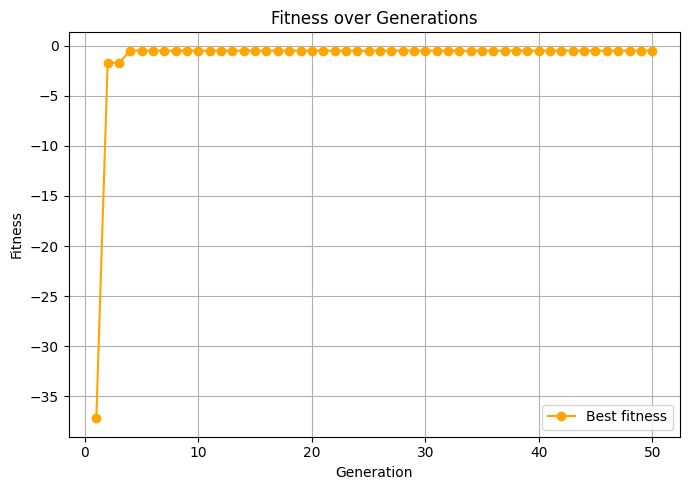

In [50]:
plot_fitness_over_generations(best_fitnesses)

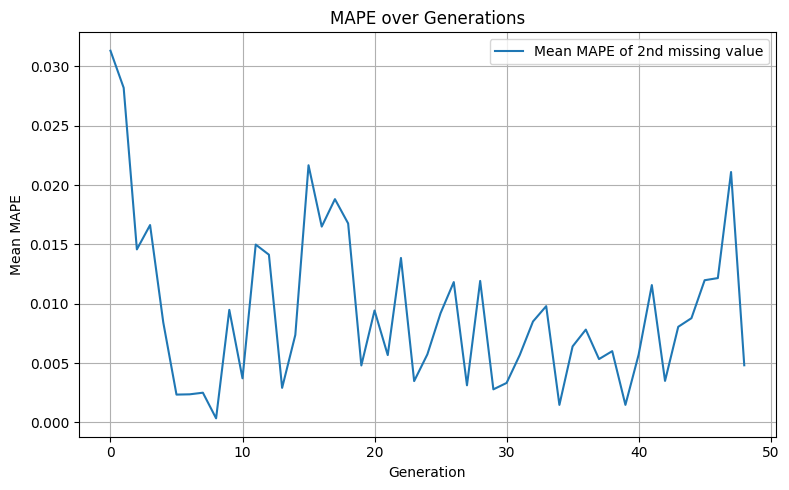

In [51]:
plot_mean_mape_over_generations(mean_maps)

In [52]:
best_predicted_nan_value = max(population, key = lambda x: x.fitness)
best_predicted_nan_value_decoded, row, col = best_predicted_nan_value.decode()
true_value = df.iloc[row, col]
print(f'True value that was hidden in the RCBD table: {true_value}')
print(f'Predicted value for null in RCBD table with GA is: {best_predicted_nan_value_decoded}')
print(f'Predicted value for second missing value in RCBD table is: {best_predicted_nan_value.second_nan}')

True value that was hidden in the RCBD table: 20.0
Predicted value for null in RCBD table with GA is: 20.7
Predicted value for second missing value in RCBD table is: 29.481250000000003


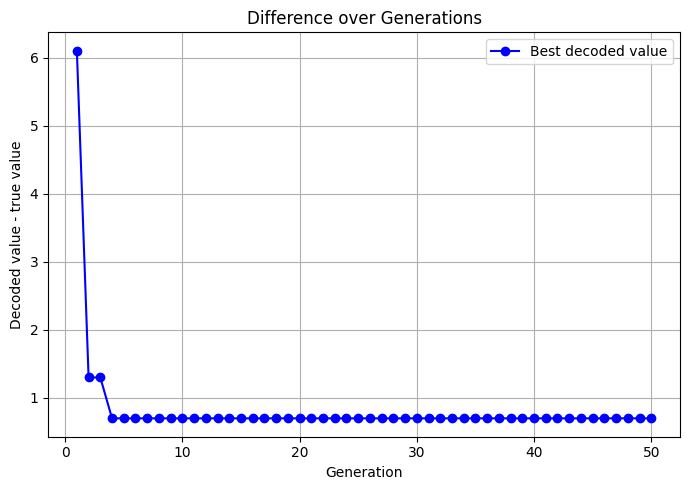

In [53]:
plot_difference_over_generations(best_decoded_values, true_value)